# ESR total-cost sensitivity analysis

This notebook compares the 2024 base case with 24 cost sensitivities for LNG, pipeline, production, regasification, liquefaction, and channel costs. Country-level changes are calculated directly, while regional changes use fixed 2024 methane-demand weights from the base input file.

The final workbook contains separate `Countries` and `Regions` sheets, and the notebook creates a tornado plot for Europe and the three Eastern/South-Eastern subregions.

## 1. Settings

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Base scenario
base_scenario = 'run_2024'

# Sensitivity types
sensitivity_types = [
    'lng',
    'pipe',
    'prod',
    'regas',
    'liqu',
    'channel',
]

# Sensitivity levels
sensitivity_levels = [
    '10pup',
    '10pdown',
    '05pup',
    '05pdown',
]

# Regions shown in the final regional results and tornado plot
regions_to_plot = [
    'Europe',
    'North-Eastern Europe',
    'Central-Eastern Europe',
    'South-Eastern Europe',
]

## 2. Paths

In [2]:
# Input data folder
input_file_path = os.path.join(
    '..', '..',
    '01_data', '01_input_data',
    '02_processed', '02_paper_ESR'
)

full_input_data_path = os.path.abspath(
    os.path.join(os.getcwd(), input_file_path)
)

# Prepared results folder
prepared_results_path = os.path.join(
    '..', '..',
    '01_data', '02_output_data',
    '02_unidirectional_results', '02_paper_ESR',
    '02_prepared_results'
)

full_prepared_results_path = os.path.abspath(
    os.path.join(os.getcwd(), prepared_results_path)
)

# Base input file containing the unchanged methane demand
input_file_name = f'inputs_ESR_2026_{base_scenario}.xlsx'
full_input_file_path = os.path.join(
    full_input_data_path, input_file_name
)

# Country-region definition file
region_file_name = 'country_regions_ESR_2024.xlsx'
full_region_file_path = os.path.join(
    full_input_data_path, region_file_name
)

# Output directory for tables and figures
figure_output_path = full_prepared_results_path

os.makedirs(figure_output_path, exist_ok=True)

## 3. Build result-file paths

In [3]:
def get_prepared_results_file(scenario_name):
    file_name = f'costs_shares_ESR_2026_{scenario_name}.xlsx'
    return os.path.join(full_prepared_results_path, file_name)

base_file = get_prepared_results_file(base_scenario)

sensitivity_files = {}

for sensitivity_type in sensitivity_types:
    for sensitivity_level in sensitivity_levels:
        scenario_name = (
            f'{base_scenario}_sens_'
            f'{sensitivity_type}_cost_{sensitivity_level}'
        )
        sensitivity_name = f'{sensitivity_type}_{sensitivity_level}'
        sensitivity_files[sensitivity_name] = get_prepared_results_file(scenario_name)

# Required-file check
required_files = {
    'base result': base_file,
    'base input': full_input_file_path,
    'region definition': full_region_file_path,
}
required_files.update(sensitivity_files)

missing_files = {
    name: path for name, path in required_files.items()
    if not os.path.exists(path)
}

if missing_files:
    raise FileNotFoundError(
        'The following required files are missing:\n'
        + '\n'.join(f'{name}: {path}' for name, path in missing_files.items())
    )

## 4. Load country groups

In [4]:
def load_country_groups(region_file):
    df_regions = pd.read_excel(region_file, sheet_name='regions')
    df_regions['Node'] = df_regions['Node'].astype(str).str.strip()

    region_columns = [
        'Europe',
        'North-Eastern Europe',
        'Central-Eastern Europe',
        'South-Eastern Europe',
    ]

    missing_regions = [
        region for region in region_columns
        if region not in df_regions.columns
    ]

    if missing_regions:
        raise ValueError(
            f'Missing region columns: {missing_regions}'
        )

    return {
        region: df_regions.loc[df_regions[region] == 1, 'Node'].tolist()
        for region in region_columns
    }

country_groups = load_country_groups(full_region_file_path)

## 5. Read the base cost table and fixed methane demand

In [5]:
def read_cost_table(file_path):
    df = pd.read_excel(file_path, sheet_name='cost')
    df['Node'] = df['Node'].astype(str).str.strip()
    return df

base_df = read_cost_table(base_file)

if 'Total Cost' not in base_df.columns:
    raise ValueError("'Total Cost' column not found in the cost sheet.")

supply_df = pd.read_excel(full_input_file_path, sheet_name='Supply')

demand_df = supply_df.loc[
    supply_df['Commodity'].astype(str).str.strip().eq('Methane'),
    ['Node', 'Supply']
].copy()

demand_df['Node'] = demand_df['Node'].astype(str).str.strip()
demand_df['Demand'] = demand_df['Supply'].abs()
demand_df = demand_df[['Node', 'Demand']]

if demand_df['Node'].duplicated().any():
    duplicates = demand_df.loc[demand_df['Node'].duplicated(), 'Node'].unique().tolist()
    raise ValueError(f'Duplicate methane demand entries found for: {duplicates}')

## 6. Add fixed demand weights

In [6]:
def add_demand_weights(cost_df, demand_df):
    df = cost_df.merge(
        demand_df,
        on='Node',
        how='left',
        validate='one_to_one'
    )

    missing_demand = df.loc[df['Demand'].isna(), 'Node'].unique().tolist()

    if missing_demand:
        raise ValueError(
            f'No methane demand found for: {missing_demand}'
        )

    return df

base_df = add_demand_weights(base_df, demand_df)

## 7. Read all 24 sensitivity cost tables

In [7]:
sensitivity_dfs = {}

for sensitivity_name, file_path in sensitivity_files.items():
    df = read_cost_table(file_path)

    if 'Total Cost' not in df.columns:
        raise ValueError(
            f"'Total Cost' column not found in {sensitivity_name}."
        )

    # Demand is unchanged across sensitivities, so use the base-case weights.
    sensitivity_dfs[sensitivity_name] = add_demand_weights(df, demand_df)

## 8. Calculate country-level changes

In [8]:
def calculate_country_changes(base_df, sensitivity_dfs):
    result = base_df[['Node', 'Total Cost']].copy()
    result = result.rename(columns={'Total Cost': 'Base'})

    for sensitivity_name, sensitivity_df in sensitivity_dfs.items():
        sensitivity_values = sensitivity_df[['Node', 'Total Cost']].copy()
        sensitivity_values = sensitivity_values.rename(
            columns={'Total Cost': sensitivity_name}
        )

        result = result.merge(
            sensitivity_values,
            on='Node',
            how='left',
            validate='one_to_one'
        )

        result[sensitivity_name] = (
            result[sensitivity_name] / result['Base'] - 1
        ) * 100

    result['Type'] = 'Country'
    return result[['Node', 'Type', 'Base'] + list(sensitivity_dfs.keys())]

country_results = calculate_country_changes(base_df, sensitivity_dfs)

## 9. Calculate demand-weighted regional changes

In [9]:
def calculate_regional_cost(df, countries):
    subset = df.loc[df['Node'].isin(countries)].copy()

    if subset.empty:
        return np.nan

    total_demand = subset['Demand'].sum()

    if total_demand == 0:
        return np.nan

    return (
        (subset['Total Cost'] * subset['Demand']).sum()
        / total_demand
    )


def calculate_regional_changes(base_df, sensitivity_dfs, country_groups):
    rows = []

    for region, countries in country_groups.items():
        base_value = calculate_regional_cost(base_df, countries)

        row = {
            'Node': region,
            'Type': 'Region',
            'Base': base_value,
        }

        for sensitivity_name, sensitivity_df in sensitivity_dfs.items():
            sensitivity_value = calculate_regional_cost(
                sensitivity_df, countries
            )

            if pd.isna(base_value) or base_value == 0:
                change = np.nan
            else:
                change = (sensitivity_value / base_value - 1) * 100

            row[sensitivity_name] = change

        rows.append(row)

    return pd.DataFrame(rows)


regional_results = calculate_regional_changes(
    base_df,
    sensitivity_dfs,
    country_groups
)

## 10. Export country and regional results

In [12]:
output_file_name = f'regional_country_sensitivity_{base_scenario}.xlsx'
output_file_path = os.path.join(
    full_prepared_results_path,
    output_file_name
)

with pd.ExcelWriter(output_file_path, engine='openpyxl') as writer:
    country_results.to_excel(
        writer, sheet_name='Countries', index=False
    )
    regional_results.to_excel(
        writer, sheet_name='Regions', index=False
    )

output_file_path

'C:\\Users\\jfg.eco\\Documents\\GitHub\\gas_infrastructure_model\\01_data\\02_output_data\\02_unidirectional_results\\02_paper_ESR\\02_prepared_results\\regional_country_sensitivity_run_2024.xlsx'

## 11. Prepare tornado-plot data

In [34]:
plot_df = regional_results.loc[
    regional_results['Node'].isin(regions_to_plot)
].copy()

plot_df = plot_df.set_index('Node')

# Sensitivity labels used on the y-axis
sensitivity_labels = {
    'prod': 'Natural Gas\nProduction\nCost',
    'liqu': 'LNG\nLiquefaction\nCost',
    'pipe': 'Pipeline\nTransport\nCost',
    'regas': 'LNG\nRegasification\nCost',
    'lng': 'LNG\nShipping\nCost',
    'channel': 'Suez and \nPanama\nCanal\nFees',
}

# Region colours
region_colors = {
    'Europe': '#163A5F',
    'North-Eastern Europe': '#2C7FB8',
    'Central-Eastern Europe': '#41AE76',
    'South-Eastern Europe': '#F36C4A',
}

# Collect 10% and 5% values
sensitivity_data = {}

for sensitivity in sensitivity_types:
    sensitivity_data[sensitivity] = {}

    for region in regions_to_plot:
        sensitivity_data[sensitivity][region] = {
            '10pup': plot_df.loc[region, f'{sensitivity}_10pup'],
            '10pdown': plot_df.loc[region, f'{sensitivity}_10pdown'],
            '05pup': plot_df.loc[region, f'{sensitivity}_05pup'],
            '05pdown': plot_df.loc[region, f'{sensitivity}_05pdown'],
        }

## 12. Order sensitivities by impact

In [35]:
# Order by the largest absolute 10% impact across the four regions.
sensitivity_order = []

for sensitivity in sensitivity_types:
    max_effect = 0

    for region in regions_to_plot:
        values = sensitivity_data[sensitivity][region]
        max_effect = max(
            max_effect,
            abs(values['10pup']),
            abs(values['10pdown'])
        )

    sensitivity_order.append((sensitivity, max_effect))

sensitivity_order = [
    name for name, _ in sorted(
        sensitivity_order,
        key=lambda x: x[1],
        reverse=True
    )
]

## 13. Create tornado plot

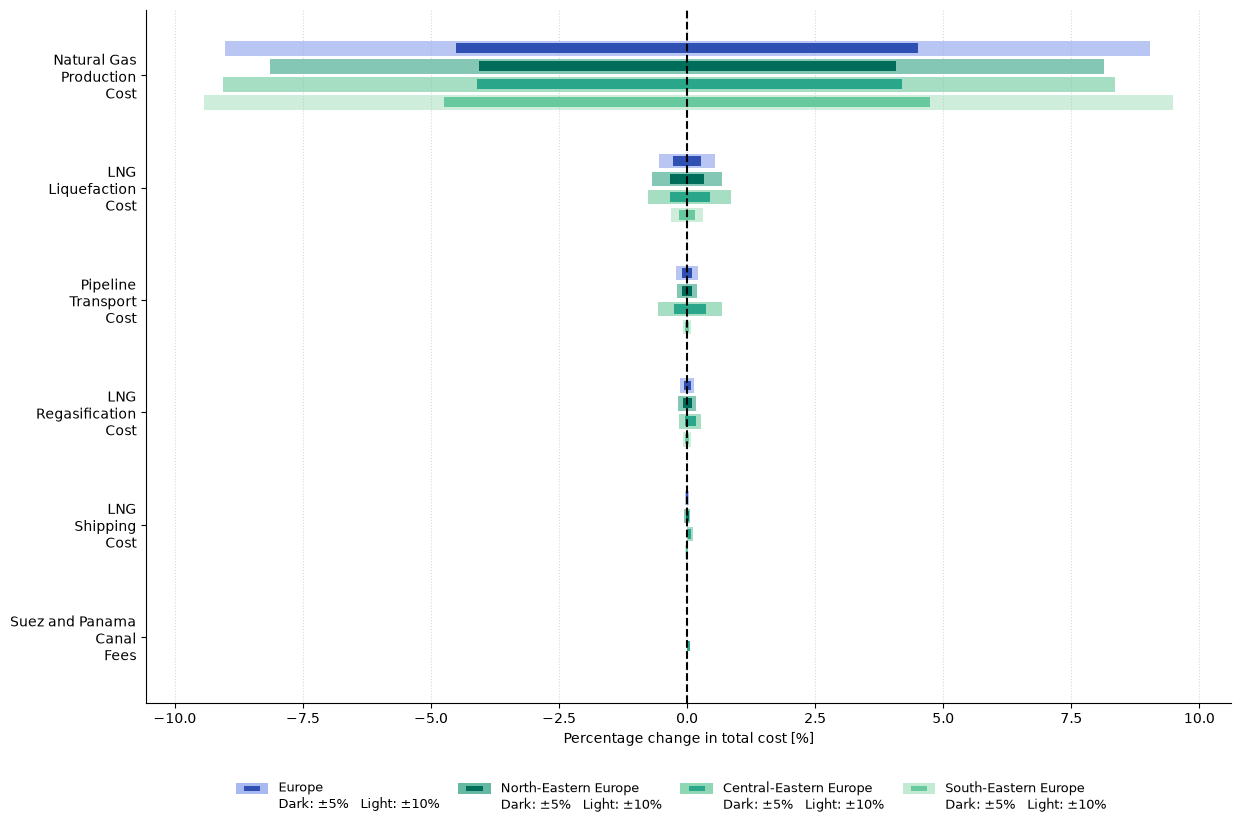

In [61]:
# ============================================================
# TORNADO PLOT
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch


# ============================================================
# REGION COLOURS
# ============================================================

# Europe: original blue
# Subregions: clearly differentiated teal-green shades
# Dark = ±5%
# Light = ±10%

region_colors_dark = {
    'Europe': '#2f4fb3',
    'North-Eastern Europe': '#006d5b',   
    'Central-Eastern Europe': '#2aa68a', 
    'South-Eastern Europe': '#69c99e',   
}

region_colors_light = {
    'Europe': '#a8b8f0',
    'North-Eastern Europe': '#65b9a3',
    'Central-Eastern Europe': '#8fd6b5', 
    'South-Eastern Europe': '#c2ead3',
}


# ============================================================
# PREPARE DATA
# ============================================================

plot_df = regional_results[
    regional_results['Node'].isin(regions_to_plot)
].copy()

plot_df = plot_df.set_index('Node')


# ============================================================
# SENSITIVITY LABELS
# ============================================================

sensitivity_labels = {
    'prod': 'Natural Gas\nProduction\nCost',
    'liqu': 'LNG\nLiquefaction\nCost',
    'pipe': 'Pipeline\nTransport\nCost',
    'regas': 'LNG\nRegasification\nCost',
    'lng': 'LNG\nShipping\nCost',
    'channel': 'Suez and Panama\nCanal\nFees',
}


# ============================================================
# PREPARE SENSITIVITY DATA
# ============================================================

sensitivity_data = {}

for sensitivity in sensitivity_types:

    sensitivity_data[sensitivity] = {}

    for region in regions_to_plot:

        sensitivity_data[sensitivity][region] = {
            '10pup': plot_df.loc[
                region,
                f'{sensitivity}_10pup'
            ],

            '10pdown': plot_df.loc[
                region,
                f'{sensitivity}_10pdown'
            ],

            '05pup': plot_df.loc[
                region,
                f'{sensitivity}_05pup'
            ],

            '05pdown': plot_df.loc[
                region,
                f'{sensitivity}_05pdown'
            ],
        }


# ============================================================
# ORDER SENSITIVITIES
# ============================================================

sensitivity_order_data = []

for sensitivity in sensitivity_types:

    max_span = 0

    for region in regions_to_plot:

        values = sensitivity_data[
            sensitivity
        ][region]

        left_10 = min(
            values['10pdown'],
            values['10pup']
        )

        right_10 = max(
            values['10pdown'],
            values['10pup']
        )

        max_span = max(
            max_span,
            right_10 - left_10
        )

    sensitivity_order_data.append(
        (
            sensitivity,
            max_span
        )
    )


sensitivity_order_data.sort(
    key=lambda x: x[1],
    reverse=True
)

sensitivity_order = [
    x[0]
    for x in sensitivity_order_data
]


# ============================================================
# COMMON X-LIMITS
# ============================================================

all_values = []

for sensitivity in sensitivity_types:

    for region in regions_to_plot:

        values = sensitivity_data[
            sensitivity
        ][region]

        all_values.extend([
            values['10pup'],
            values['10pdown'],
            values['05pup'],
            values['05pdown'],
        ])


x_min = min(all_values)
x_max = max(all_values)

x_range = x_max - x_min

pad = x_range * 0.06

common_xlim = (
    x_min - pad,
    x_max + pad
)


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 9)
)


# ============================================================
# BAR POSITIONS
# ============================================================

y = np.arange(
    len(sensitivity_order)
)

# More vertical space between sensitivity groups
# to prevent the four regional bars from overlapping.
group_spacing = 1.25

y = y * group_spacing

# Positions of the four regional bars within each group
region_offsets = np.array([
    -0.30,
    -0.10,
     0.10,
     0.30,
])

# Bar heights are now smaller than the distance between bars
bar_height_10 = 0.16
bar_height_05 = 0.11


# ============================================================
# DRAW BARS
# ============================================================

for i, sensitivity in enumerate(
    sensitivity_order
):

    for region_index, region in enumerate(
        regions_to_plot
    ):

        values = sensitivity_data[
            sensitivity
        ][region]

        y_pos = (
            y[i]
            + region_offsets[region_index]
        )


        # ----------------------------------------------------
        # 10% RANGE - LIGHT
        # ----------------------------------------------------

        left_10 = min(
            values['10pdown'],
            values['10pup']
        )

        right_10 = max(
            values['10pdown'],
            values['10pup']
        )

        ax.barh(
            y_pos,
            right_10 - left_10,
            left=left_10,
            height=bar_height_10,
            color=region_colors_light[region],
            alpha=0.8,
            edgecolor='none',
            zorder=1,
        )


        # ----------------------------------------------------
        # 5% RANGE - DARK
        # ----------------------------------------------------

        left_05 = min(
            values['05pdown'],
            values['05pup']
        )

        right_05 = max(
            values['05pdown'],
            values['05pup']
        )

        ax.barh(
            y_pos,
            right_05 - left_05,
            left=left_05,
            height=bar_height_05,
            color=region_colors_dark[region],
            edgecolor='none',
            zorder=2,
        )


# ============================================================
# ZERO LINE
# ============================================================

ax.axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=1.5,
    zorder=4,
)


# ============================================================
# AXES
# ============================================================

ax.set_yticks(y)

ax.set_yticklabels(
    [
        sensitivity_labels[sensitivity]
        for sensitivity in sensitivity_order
    ]
)

ax.invert_yaxis()

ax.set_xlabel(
    'Percentage change in total cost [%]'
)

ax.set_xlim(
    common_xlim
)

ax.grid(
    axis='x',
    linestyle=':',
    alpha=0.5
)


# ============================================================
# SPINES
# ============================================================

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# ============================================================
# CUSTOM LEGEND
# ============================================================

from matplotlib.legend_handler import HandlerBase
from matplotlib.patches import Rectangle


class HandlerSensitivityBar(HandlerBase):
    """
    Custom legend handle reproducing the tornado-bar structure:
    light/wider = ±10%
    dark/narrower = ±5%
    """

    def create_artists(
        self,
        legend,
        orig_handle,
        xdescent,
        ydescent,
        width,
        height,
        fontsize,
        trans
    ):

        dark_color, light_color = orig_handle

        # Centre the complete graphical element vertically
        center_y = ydescent + height * 0.5

        outer_height = height * 0.60
        inner_height = height * 0.32

        # Wide/light ±10% bar
        outer_bar = Rectangle(
            (
                xdescent,
                center_y - outer_height / 2
            ),
            width,
            outer_height,
            facecolor=light_color,
            edgecolor='none',
            transform=trans,
        )

        # Narrow/dark ±5% bar
        inner_bar = Rectangle(
            (
                xdescent + width * 0.25,
                center_y - inner_height / 2
            ),
            width * 0.50,
            inner_height,
            facecolor=dark_color,
            edgecolor='none',
            transform=trans,
        )

        return [
            outer_bar,
            inner_bar
        ]


# ============================================================
# LEGEND LABELS
# ============================================================

legend_labels = [
    f'{region}\nDark: ±5%   Light: ±10%'
    for region in regions_to_plot
]


# ============================================================
# LEGEND HANDLES
# ============================================================

legend_handles = [
    (
        region_colors_dark[region],
        region_colors_light[region]
    )
    for region in regions_to_plot
]


# ============================================================
# LEGEND
# ============================================================

fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    handler_map={
        tuple: HandlerSensitivityBar()
    },
    loc='lower center',
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.025),
    fontsize=9,
    handlelength=2.6,
    handleheight=1.8,
    handletextpad=0.8,
    columnspacing=1.5,
)


# ============================================================
# SAVE
# ============================================================

figure_name = (
    'tornado_plot_ESR_regional_sensitivities'
)

png_file = os.path.join(
    full_prepared_results_path,
    figure_name + '.png'
)

pdf_file = os.path.join(
    full_prepared_results_path,
    figure_name + '.pdf'
)

plt.savefig(
    png_file,
    dpi=300,
    bbox_inches='tight',
    facecolor='white',
)

plt.savefig(
    pdf_file,
    bbox_inches='tight',
    facecolor='white',
)


# ============================================================
# SHOW
# ============================================================

plt.show()

## 14. Save tornado plot

In [51]:
figure_base_name = f'tornado_total_cost_sensitivity_{base_scenario}'

figure_png_path = os.path.join(
    figure_output_path,
    figure_base_name + '.png'
)

figure_pdf_path = os.path.join(
    figure_output_path,
    figure_base_name + '.pdf'
)

fig.savefig(
    figure_png_path,
    dpi=300,
    bbox_inches='tight'
)

fig.savefig(
    figure_pdf_path,
    bbox_inches='tight'
)

(figure_png_path, figure_pdf_path)

('C:\\Users\\jfg.eco\\Documents\\GitHub\\gas_infrastructure_model\\01_data\\02_output_data\\02_unidirectional_results\\02_paper_ESR\\02_prepared_results\\tornado_total_cost_sensitivity_run_2024.png',
 'C:\\Users\\jfg.eco\\Documents\\GitHub\\gas_infrastructure_model\\01_data\\02_output_data\\02_unidirectional_results\\02_paper_ESR\\02_prepared_results\\tornado_total_cost_sensitivity_run_2024.pdf')